### UMAP algoritmo pavyzdžiai

In [1]:
import umap
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

/home/user/Documents/repositories/ais-duomenu-vizualizavimas/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ellipsoid = pd.read_csv('./ellipsoid.50d10c.8.txt', sep='\t', header=None)

In [3]:
iris = pd.read_csv('./iris_with_class.txt', sep='\t', header=None)

In [4]:
iris[4] = iris[4].map({'Iris-setosa':1,
                       'Iris-versicolor':2,
                       'Iris-virginica':3})

In [5]:
mnist = pd.read_csv('./mnist_train.csv')
print(mnist.columns.tolist())
X_mnist = mnist.iloc[:, 1:].values   # features
y = mnist.iloc[:, 0].values    # labels
print(X_mnist.shape)

['label', '1x1', '1x2', '1x3', '1x4', '1x5', '1x6', '1x7', '1x8', '1x9', '1x10', '1x11', '1x12', '1x13', '1x14', '1x15', '1x16', '1x17', '1x18', '1x19', '1x20', '1x21', '1x22', '1x23', '1x24', '1x25', '1x26', '1x27', '1x28', '2x1', '2x2', '2x3', '2x4', '2x5', '2x6', '2x7', '2x8', '2x9', '2x10', '2x11', '2x12', '2x13', '2x14', '2x15', '2x16', '2x17', '2x18', '2x19', '2x20', '2x21', '2x22', '2x23', '2x24', '2x25', '2x26', '2x27', '2x28', '3x1', '3x2', '3x3', '3x4', '3x5', '3x6', '3x7', '3x8', '3x9', '3x10', '3x11', '3x12', '3x13', '3x14', '3x15', '3x16', '3x17', '3x18', '3x19', '3x20', '3x21', '3x22', '3x23', '3x24', '3x25', '3x26', '3x27', '3x28', '4x1', '4x2', '4x3', '4x4', '4x5', '4x6', '4x7', '4x8', '4x9', '4x10', '4x11', '4x12', '4x13', '4x14', '4x15', '4x16', '4x17', '4x18', '4x19', '4x20', '4x21', '4x22', '4x23', '4x24', '4x25', '4x26', '4x27', '4x28', '5x1', '5x2', '5x3', '5x4', '5x5', '5x6', '5x7', '5x8', '5x9', '5x10', '5x11', '5x12', '5x13', '5x14', '5x15', '5x16', '5x17', '5x

In [6]:
swiss = pd.read_csv("swiss_roll_example.csv", sep=";", header=None)
print(swiss.shape)

X_swiss = swiss.values
color = X_swiss[:, 0]   # color gradient similar to sklearn swiss roll

(400, 3)


### UMAP hiperparametrų keitimas

In [11]:
def plot_iris(data, n_neighbors=15, min_dist=0.1, metric='euclidean', n_epochs=None, learning_rate=1.0, ax=None, var='n_neighbors'):
    data_umap = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, metric=metric, n_epochs=n_epochs, learning_rate=learning_rate, random_state=42).fit_transform(iris[[0, 1, 2, 3]])

    if ax is None:
        ax = plt.gca()

    ax.scatter(data_umap[:, 0], data_umap[:, 1], s=28, alpha=0.8, c=iris[4])
    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_title(f"{var}={locals()[var]}", size=24)

In [14]:
def plot_ellipsoid(data, labels=None, n_neighbors=15, min_dist=0.1, metric='euclidean', n_epochs=None, learning_rate=1.0, ax=None, var='n_neighbors'):
    data_umap = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, metric=metric, n_epochs=n_epochs, learning_rate=learning_rate, random_state=42).fit_transform(data)
    
    if ax is None:
        ax = plt.gca()

    if labels is not None:
        ax.scatter(data_umap[:, 0], data_umap[:, 1], s=28, alpha=0.8, c=labels, cmap='tab10')
        ax.set_xticks([])
        ax.set_yticks([])
    else:
        ax.scatter(data_umap[:, 0], data_umap[:, 1], s=28, alpha=0.8)
        ax.set_xticks([])
        ax.set_yticks([])

    ax.set_title(f"{var}={locals()[var]}", size=24)

In [42]:
def plot_mnist(
    data,
    labels=None,
    n_neighbors=15,
    min_dist=0.1,
    metric='euclidean',
    n_epochs=None,
    learning_rate=1.0,
    ax=None,
    var='n_neighbors'
):

    reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric=metric,
        n_epochs=n_epochs,
        learning_rate=learning_rate,
        random_state=42
    )

    data_umap = reducer.fit_transform(data)

    if ax is None:
        ax = plt.gca()

    ax.scatter(
        data_umap[:, 0],
        data_umap[:, 1],
        c=labels,
        cmap='tab10',
        s=15,
        alpha=0.8
    )

    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_title(f"{var}={locals()[var]}", size=19)

In [43]:
def plot_swiss(
    data,
    n_neighbors=15,
    min_dist=0.1,
    metric='euclidean',
    n_epochs=None,
    learning_rate=1.0,
    ax=None,
    var='n_neighbors'
):

    reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric=metric,
        n_epochs=n_epochs,
        learning_rate=learning_rate,
        random_state=42,
    )

    data_umap = reducer.fit_transform(data)

    if ax is None:
        ax = plt.gca()

    ax.scatter(
        data_umap[:, 0],
        data_umap[:, 1],
        c=data[:, 0],        # color by original coordinate
        cmap='Spectral',
        s=15,
        alpha=0.8
    )

    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_title(f"{var}={locals()[var]}", size=19)

#### Kintamojo `n_neighbors` įtaka

/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_stat

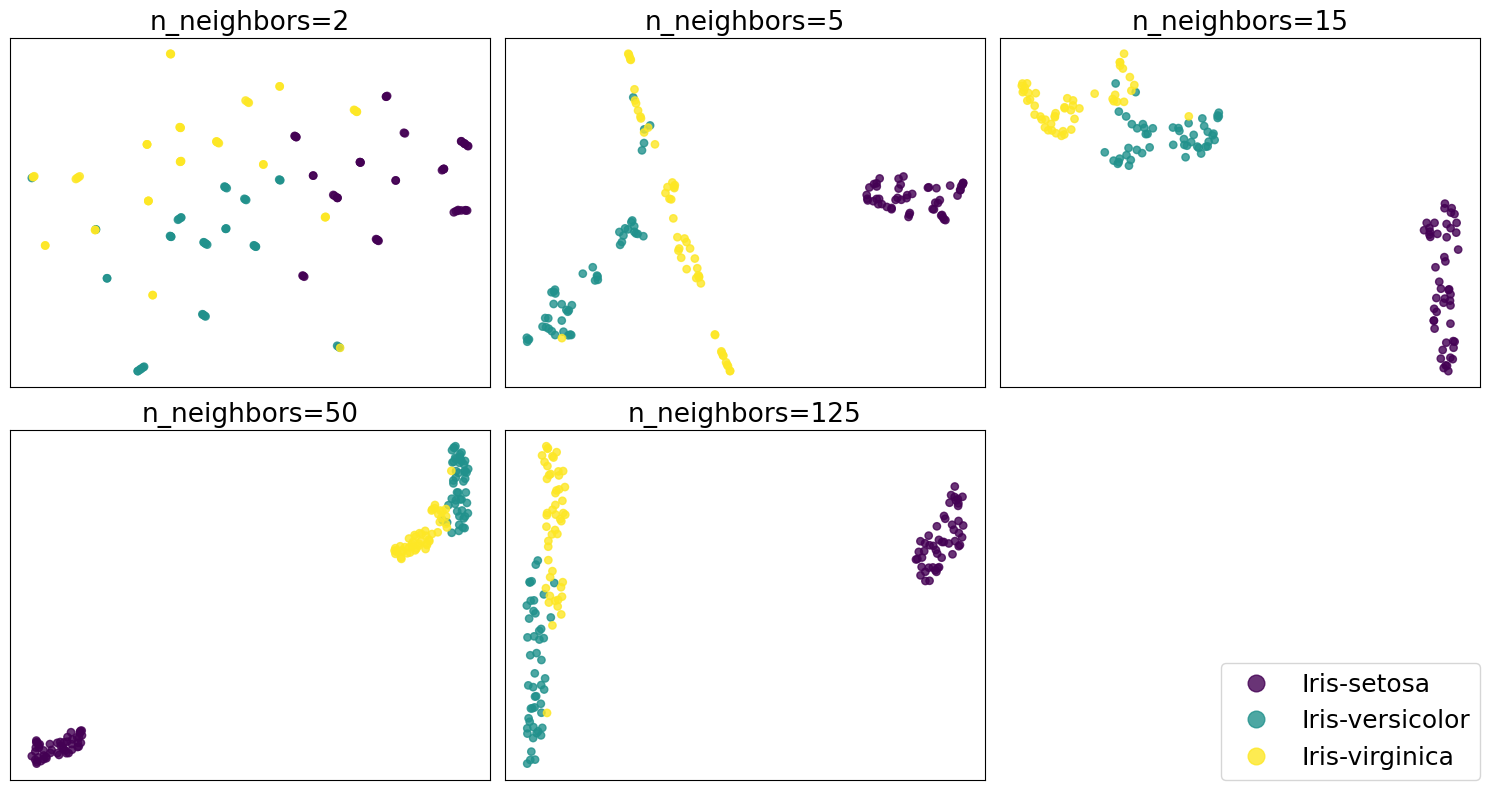

In [23]:
neighbors_values = [2, 5, 15, 50, 125]
fig, axs = plt.subplots(2, 3, figsize=(15, 8))
axs = axs.flatten()
# fig.suptitle('Skirtumai keičiant n_neighbors Iris duomenims ($min-dist=0.1$, euclidean)', fontsize=14)

for i, n in enumerate(neighbors_values):
    plot_iris(iris[[0, 1, 2, 3]], n_neighbors=n, ax=axs[i])

axs[-1].axis('off')

handles, _ = axs[0].collections[0].legend_elements()

fig.legend(
    handles,
    ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'],
    loc='lower right',
    fontsize=18,     
    markerscale=2.0  
)

plt.tight_layout()
plt.savefig("neighbors_iris.png", dpi=300, bbox_inches="tight")
plt.show()

/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_stat

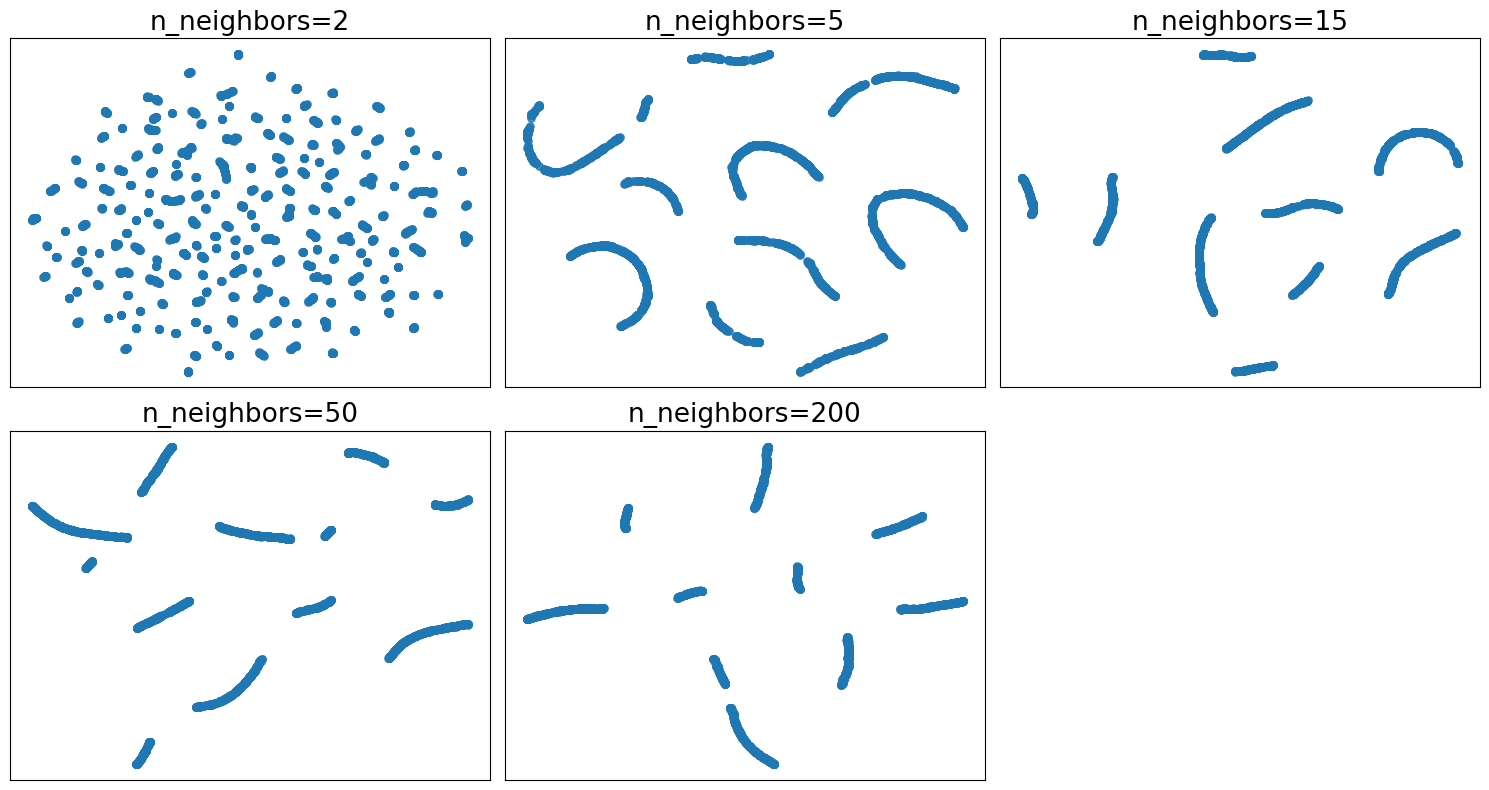

In [24]:
neighbors_values = [2, 5, 15, 50, 200]
fig, axs = plt.subplots(2, 3, figsize=(15, 8))
axs = axs.flatten()
# fig.suptitle('Skirtumai keičiant n_neighbors Ellipsoid duomenims ($min-dist=0.1$, euclidean)', fontsize=14)

for i, n in enumerate(neighbors_values):
    plot_ellipsoid(ellipsoid, n_neighbors=n, ax=axs[i])

axs[-1].axis('off')

plt.tight_layout()
plt.savefig("neighbors_ellipsoid.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
neighbors_values = [2, 5, 15, 50, 200]

fig, axs = plt.subplots(2, 3, figsize=(15, 8))
axs = axs.flatten()
# fig.suptitle(
#     'Skirtumai keičiant n_neighbors MNIST duomenims ($min-dist=0.1$, euclidean)',
#     fontsize=14
# )

for i, n in enumerate(neighbors_values):
    plot_mnist(X_mnist, y, n_neighbors=n, ax=axs[i])

axs[-1].axis('off')

plt.tight_layout()
plt.savefig("neighbors_mnist.png", dpi=300, bbox_inches="tight")
plt.show()

/home/user/Documents/repositories/ais-duomenu-vizualizavimas/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/user/Documents/repositories/ais-duomenu-vizualizavimas/.venv/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/home/user/Documents/repositories/ais-duomenu-vizualizavimas/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/user/Documents/repositories/ais-duomenu-vizualizavimas/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/user/Documents/repositories/ais-duomenu-vizualizavimas/.venv/lib/python3.12/site-p

TypeError: plot_swiss() got multiple values for argument 'n_neighbors'

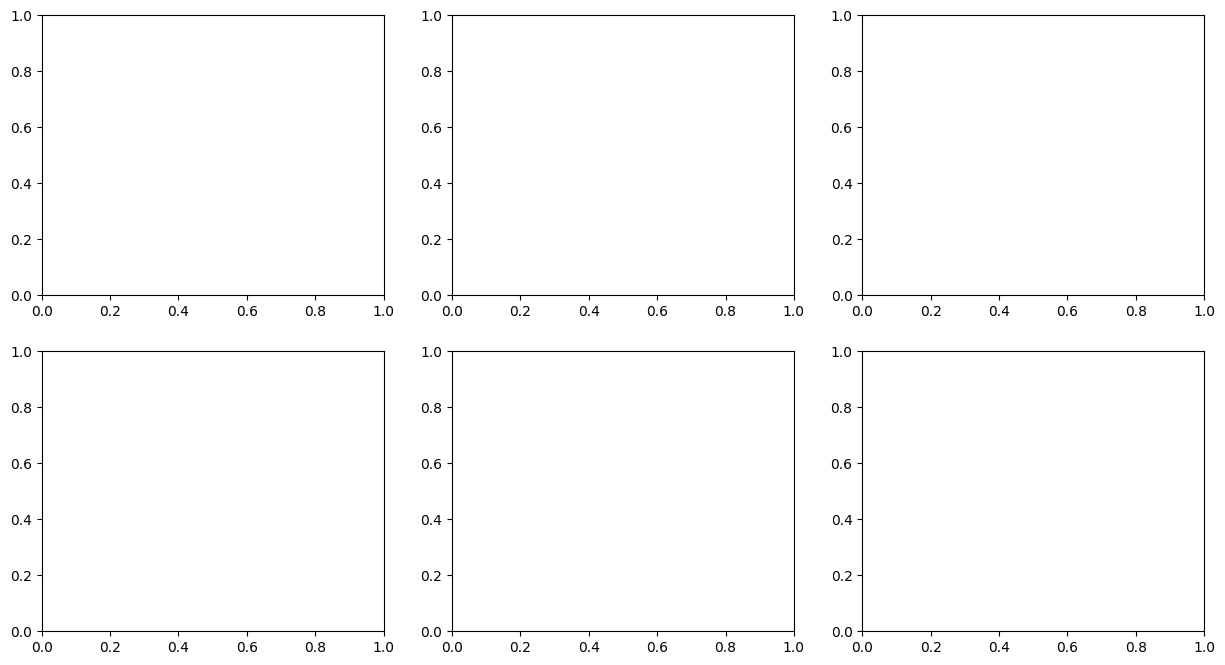

In [47]:
neighbors_values = [2, 5, 15, 50, 200]

fig, axs = plt.subplots(2, 3, figsize=(15, 8))
axs = axs.flatten()
# fig.suptitle(
#     'Skirtumai keičiant n_neighbors SWISS duomenims ($min-dist=0.1$, euclidean)',
#     fontsize=14
# )

for i, n in enumerate(neighbors_values):
    plot_swiss(X_swiss, color, n_neighbors=n, ax=axs[i])

axs[-1].axis('off')

plt.tight_layout()
plt.savefig("neighbors_swiss.png", dpi=300, bbox_inches="tight")
plt.show()

#### Kintamojo `min_dist` įtaka

/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_stat

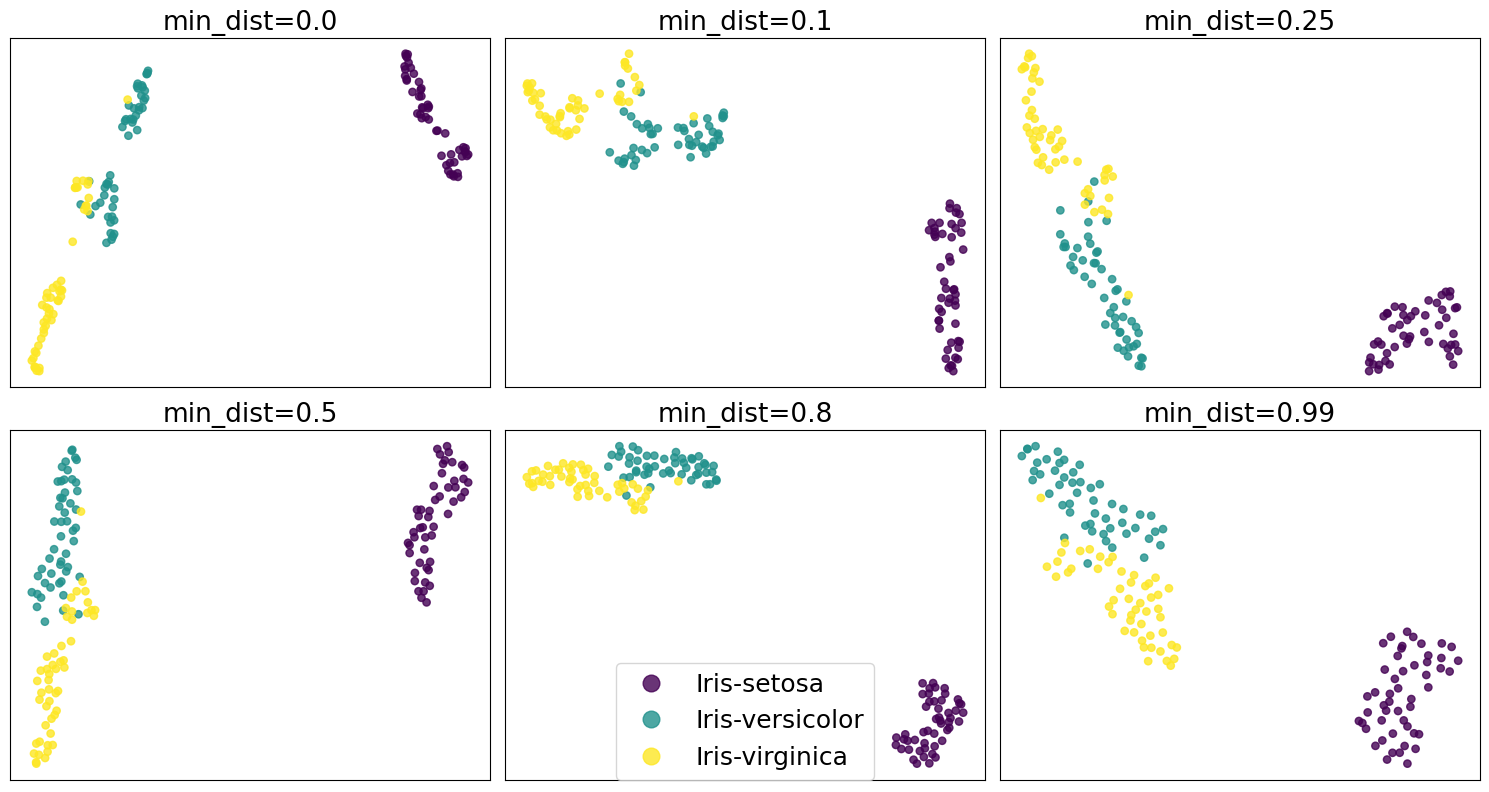

In [27]:
dist_values = [0.0, 0.1, 0.25, 0.5, 0.8, 0.99]
fig, axs = plt.subplots(2, 3, figsize=(15, 8))
axs = axs.flatten()

for i, d in enumerate(dist_values):
    plot_iris(iris[[0, 1, 2, 3]], min_dist=d, ax=axs[i], var='min_dist')

handles, _ = axs[0].collections[0].legend_elements()

fig.legend(
    handles,
    ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'],
    loc='lower center',
    fontsize=18,
    markerscale=2
)

plt.tight_layout()
plt.savefig("mindist_iris.png", dpi=300, bbox_inches="tight")
plt.show()

/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_stat

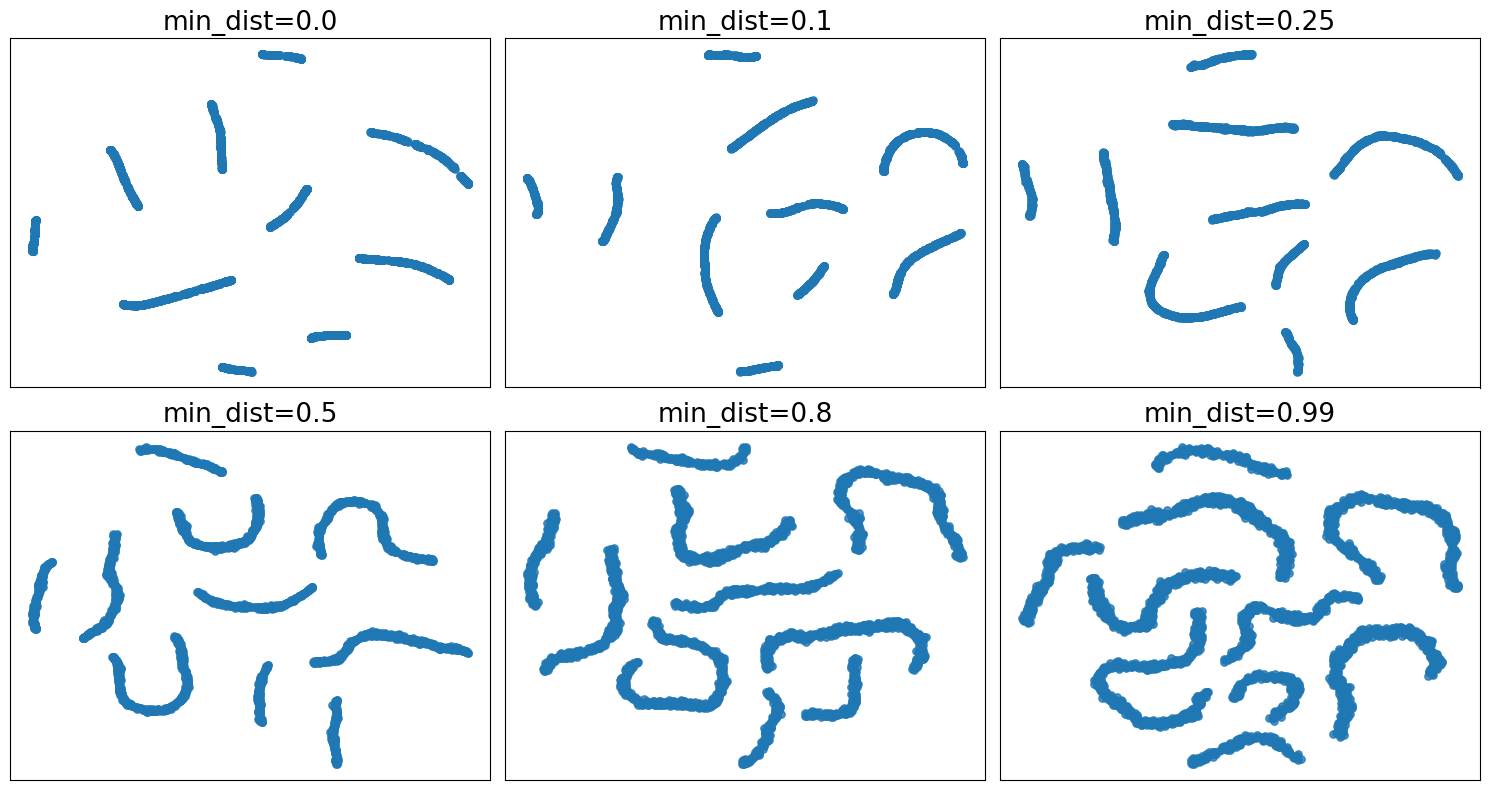

In [28]:
dist_values = [0.0, 0.1, 0.25, 0.5, 0.8, 0.99]
fig, axs = plt.subplots(2, 3, figsize=(15, 8))
axs = axs.flatten()
# fig.suptitle('Skirtumai keičiant min_dist Ellipsoid duomenims ($k=15$, euclidean)', fontsize=14)

for i, d in enumerate(dist_values):
    plot_ellipsoid(ellipsoid, min_dist=d, ax=axs[i], var='min_dist')

plt.tight_layout()
plt.savefig("mindist_ellipsoid.png", dpi=300, bbox_inches="tight")
plt.show()

/home/user/Documents/repositories/ais-duomenu-vizualizavimas/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/user/Documents/repositories/ais-duomenu-vizualizavimas/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/user/Documents/repositories/ais-duomenu-vizualizavimas/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/user/Documents/repositories/ais-duomenu-vizualizavimas/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/user/Documents/repositories/ais-duomenu-vizualizavimas/.venv/lib/python3.12/site-packages/umap/umap_.py:19

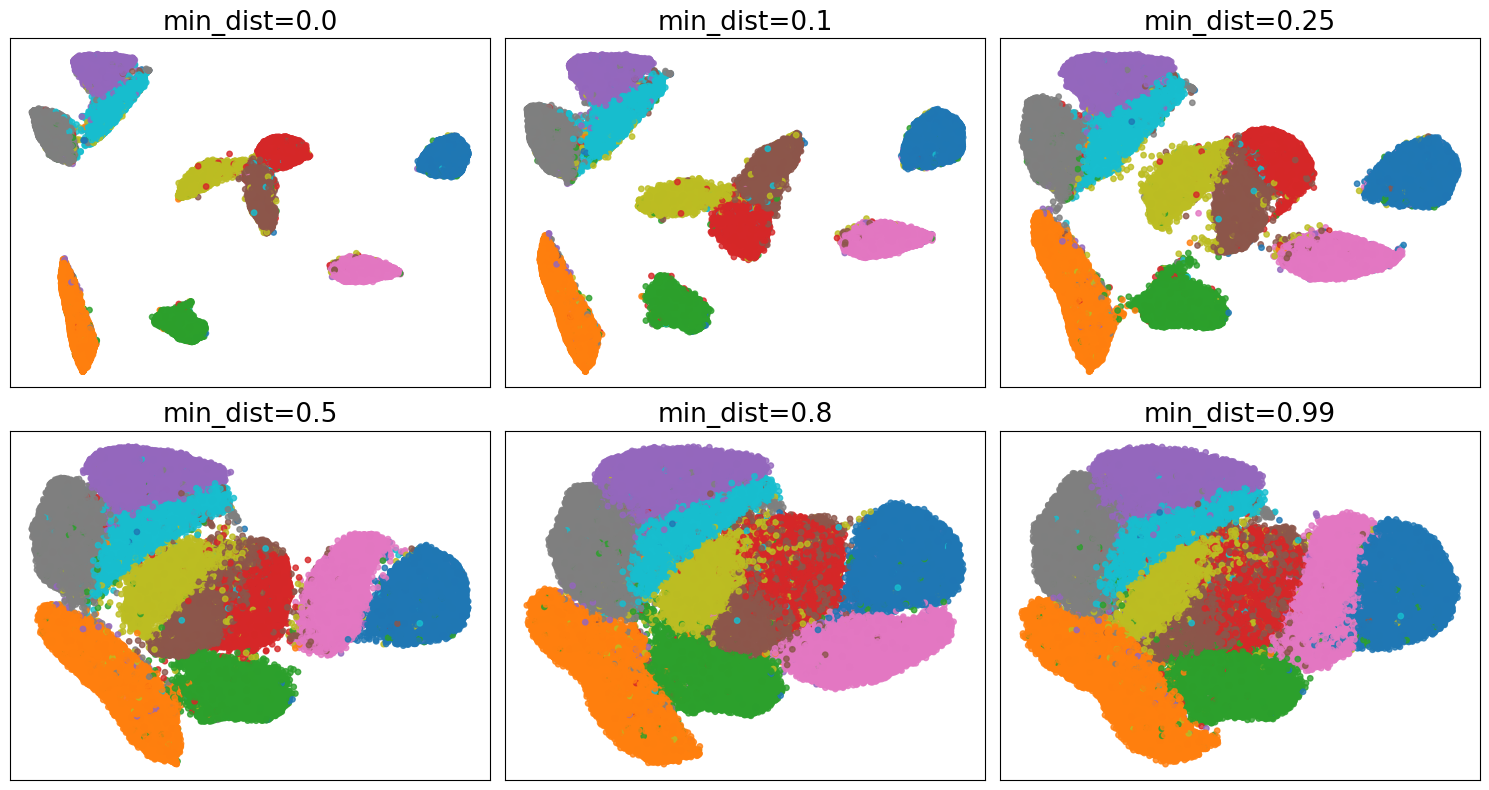

In [45]:
dist_values = [0.0, 0.1, 0.25, 0.5, 0.8, 0.99]

fig, axs = plt.subplots(2, 3, figsize=(15, 8))
axs = axs.flatten()
# fig.suptitle(
#     'Skirtumai keičiant min_dist MNIST duomenims ($k=15$, euclidean)',
#     fontsize=14
# )

for i, d in enumerate(dist_values):
    plot_mnist(X_mnist, y, min_dist=d, ax=axs[i], var='min_dist')

plt.tight_layout()
plt.savefig("mindist_mnist.png", dpi=300, bbox_inches="tight")
plt.show()

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

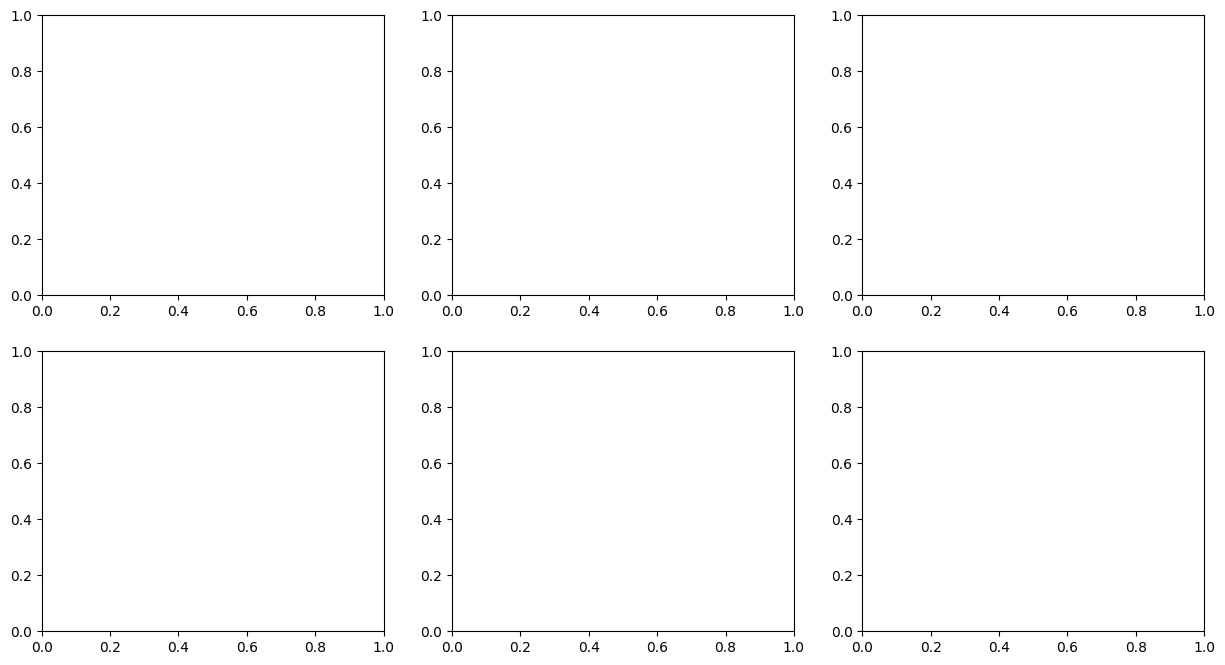

In [46]:
dist_values = [0.0, 0.1, 0.25, 0.5, 0.8, 0.99]

fig, axs = plt.subplots(2, 3, figsize=(15, 8))
axs = axs.flatten()
# fig.suptitle(
#     'Skirtumai keičiant min_dist SWISS duomenims ($k=15$, euclidean)',
#     fontsize=14
# )

for i, d in enumerate(dist_values):
    plot_swiss(X_swiss, color, min_dist=d, ax=axs[i], var='min_dist')

plt.tight_layout()
plt.savefig("mindist_swiss.png", dpi=300, bbox_inches="tight")
plt.show()

#### Kintamojo `metric` įtaka

In [12]:
metrics = ['euclidean', 'manhattan', 'chebyshev', 'cosine']

/home/user/Documents/repositories/ais-duomenu-vizualizavimas/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/user/Documents/repositories/ais-duomenu-vizualizavimas/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/user/Documents/repositories/ais-duomenu-vizualizavimas/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/user/Documents/repositories/ais-duomenu-vizualizavimas/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


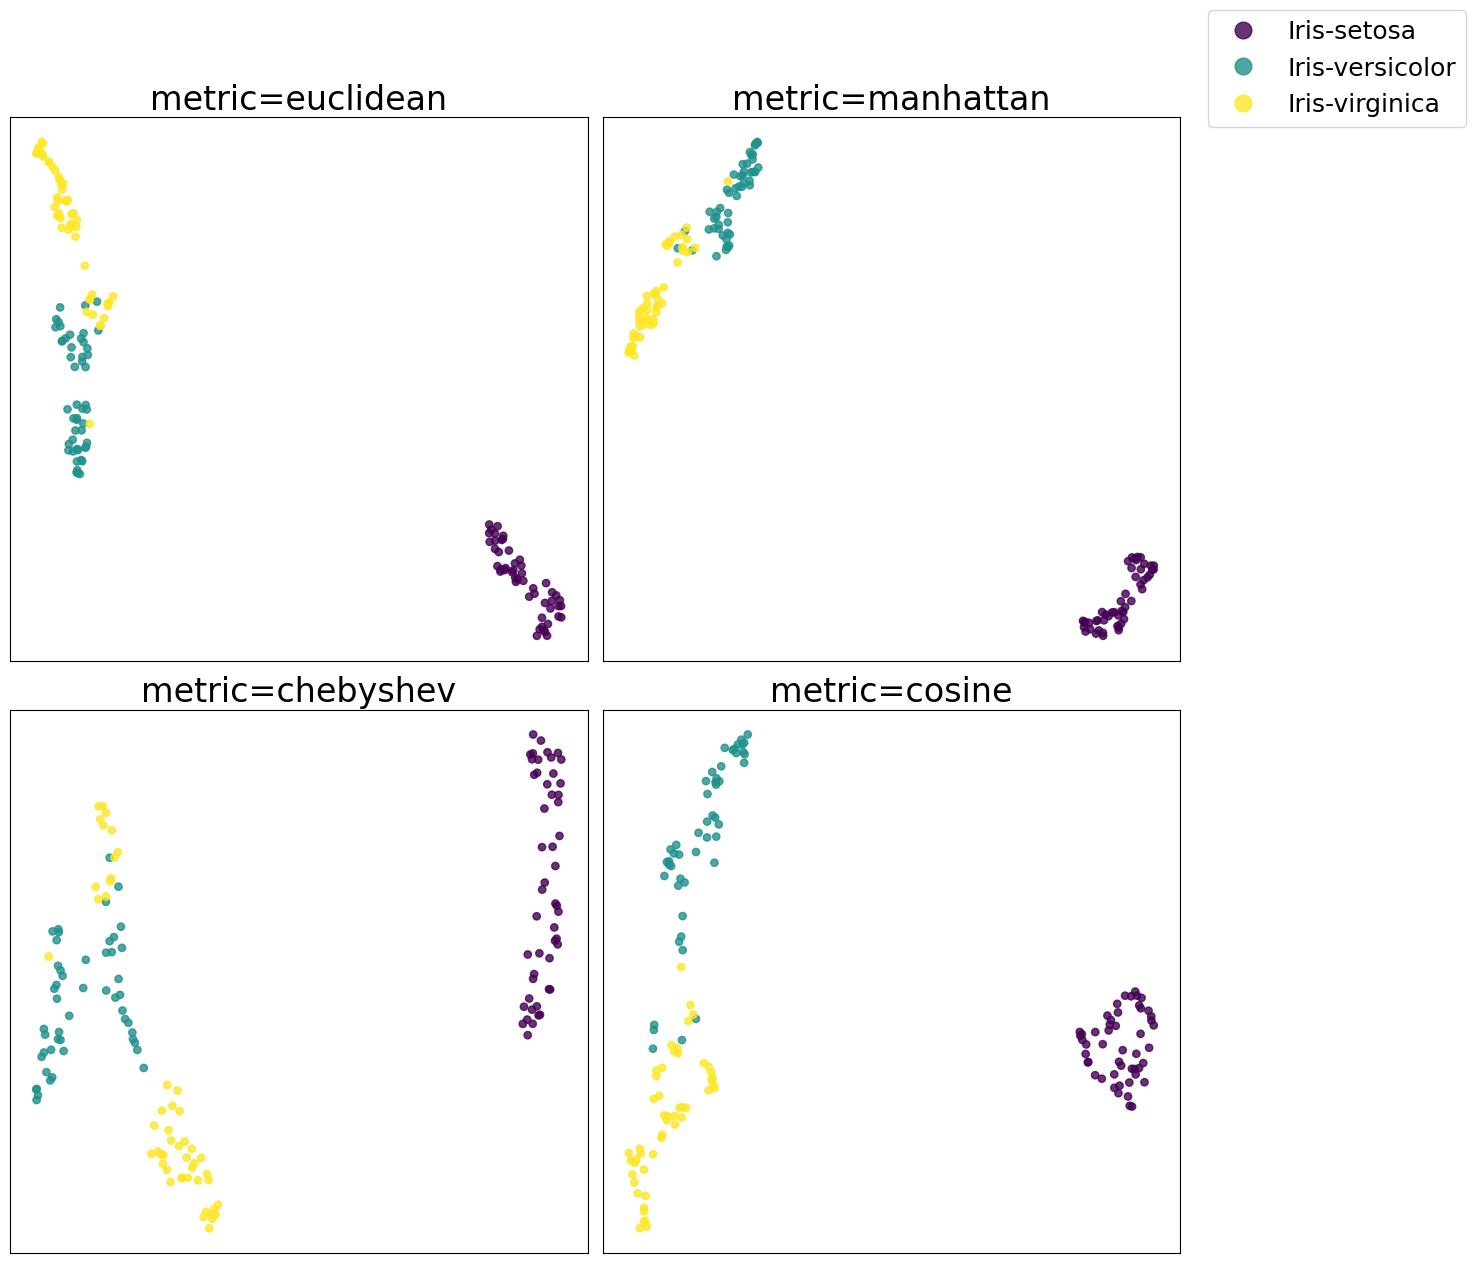

In [13]:
fig, axs = plt.subplots(2, 2, figsize=(12, 12))
axs = axs.flatten()

# fig.suptitle('Skirtumai keičiant metric Iris duomenims ($k=15$, $min-dist=0.1$)', fontsize=14)

for i, m in enumerate(metrics):
    plot_iris(iris[[0, 1, 2, 3]], metric=m, ax=axs[i], var='metric')

handles, _ = axs[0].collections[0].legend_elements()

fig.legend(
    handles,
    ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'],
    loc='center left',
    bbox_to_anchor=(1.0, 1),
    fontsize=18,
    markerscale=2
)

plt.tight_layout()
plt.savefig("metric_iris.png", dpi=300, bbox_inches="tight")
plt.show()

/home/user/Documents/repositories/ais-duomenu-vizualizavimas/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/user/Documents/repositories/ais-duomenu-vizualizavimas/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/user/Documents/repositories/ais-duomenu-vizualizavimas/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/user/Documents/repositories/ais-duomenu-vizualizavimas/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


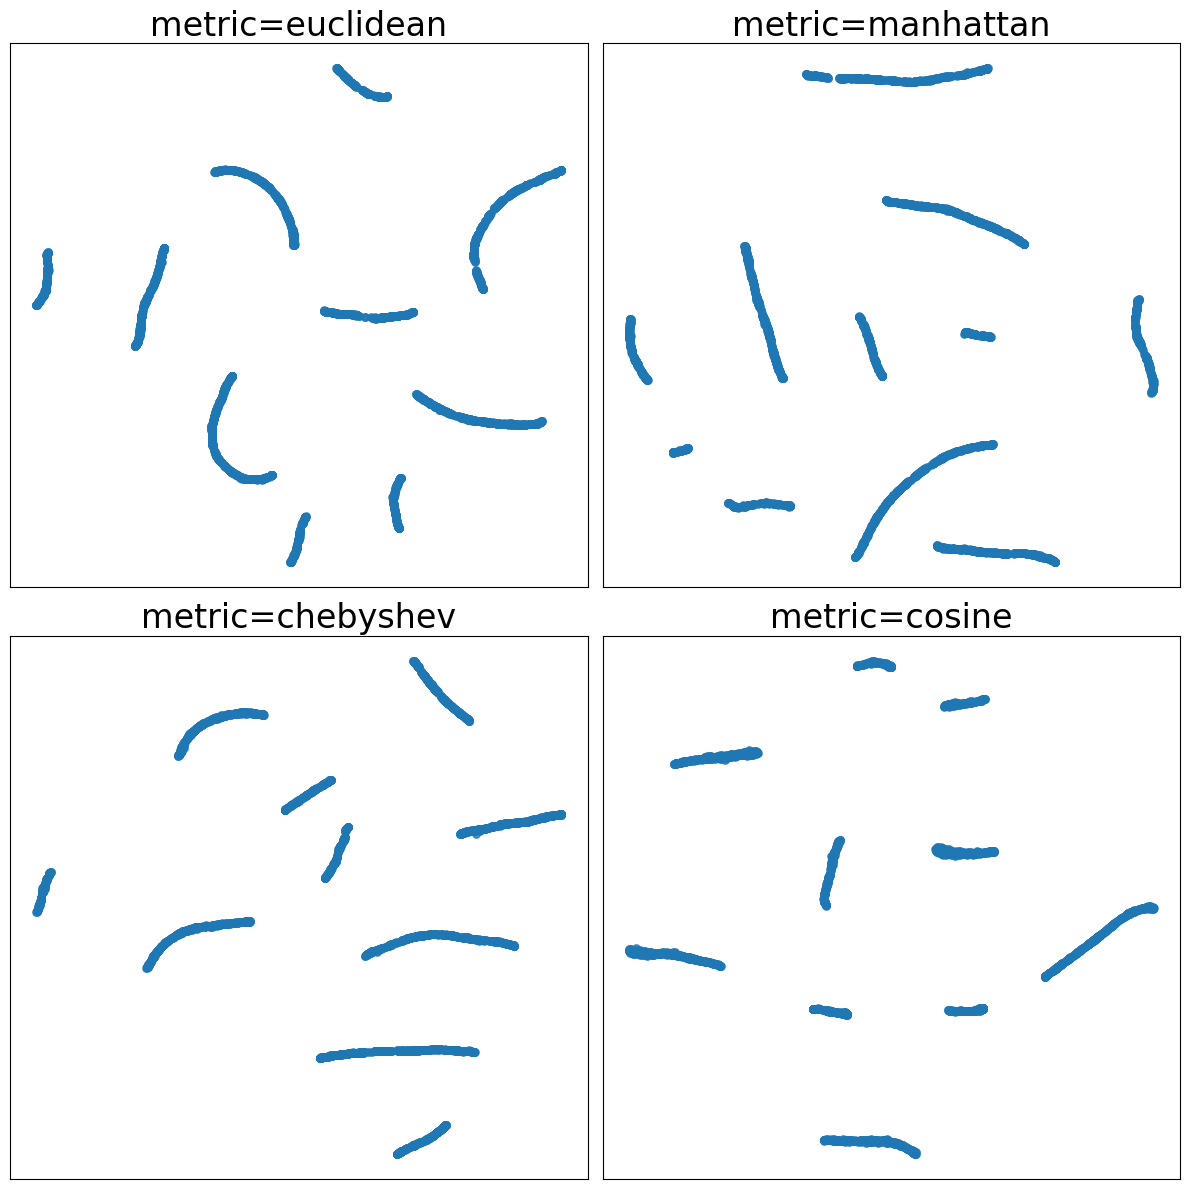

In [15]:
fig, axs = plt.subplots(2, 2, figsize=(12, 12))
axs = axs.flatten()
# fig.suptitle('Skirtumai keičiant metric Ellipsoid duomenims ($k=15$, $min-dist=0.1$)', fontsize=14)

for i, m in enumerate(metrics):
    plot_ellipsoid(ellipsoid, metric=m, ax=axs[i], var='metric')

plt.tight_layout()
plt.savefig("metric_ellipsoid.png", dpi=300, bbox_inches="tight")
plt.show()

/home/user/Documents/repositories/ais-duomenu-vizualizavimas/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/user/Documents/repositories/ais-duomenu-vizualizavimas/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/user/Documents/repositories/ais-duomenu-vizualizavimas/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/user/Documents/repositories/ais-duomenu-vizualizavimas/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


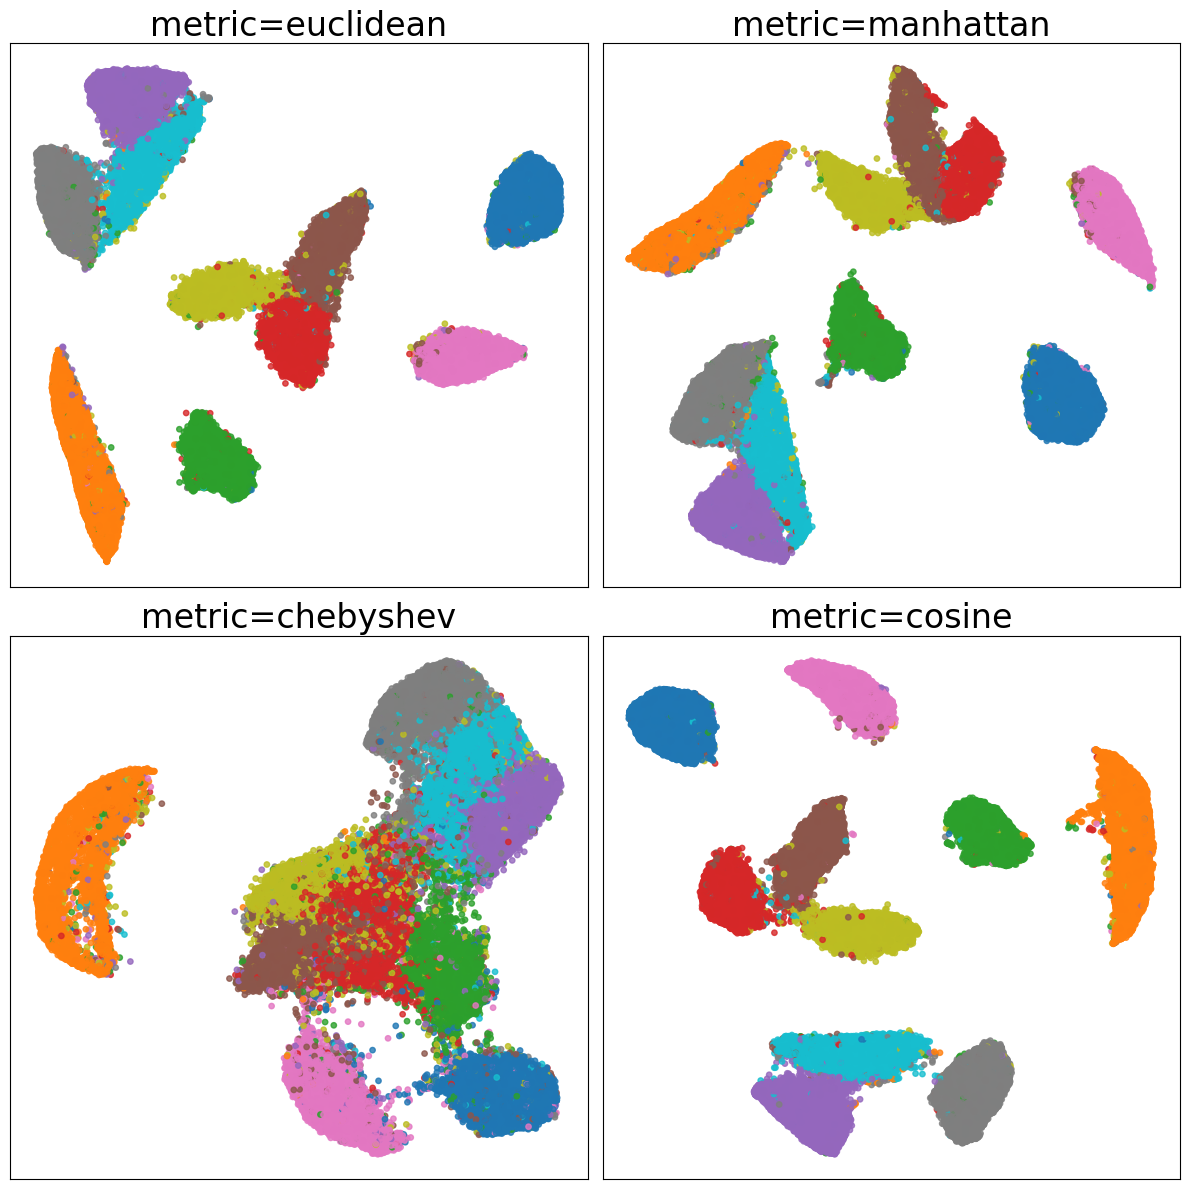

In [40]:
fig, axs = plt.subplots(2, 2, figsize=(12, 12))
axs = axs.flatten()
# fig.suptitle(
#     'Skirtumai keičiant metric MNIST duomenims ($k=15$, $min-dist=0.1$)',
#     fontsize=14
# )

for i, m in enumerate(metrics):
    plot_mnist(X_mnist, y, metric=m, ax=axs[i], var='metric')

plt.tight_layout()
plt.savefig("metric_mnist.png", dpi=300, bbox_inches="tight")
plt.show()

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

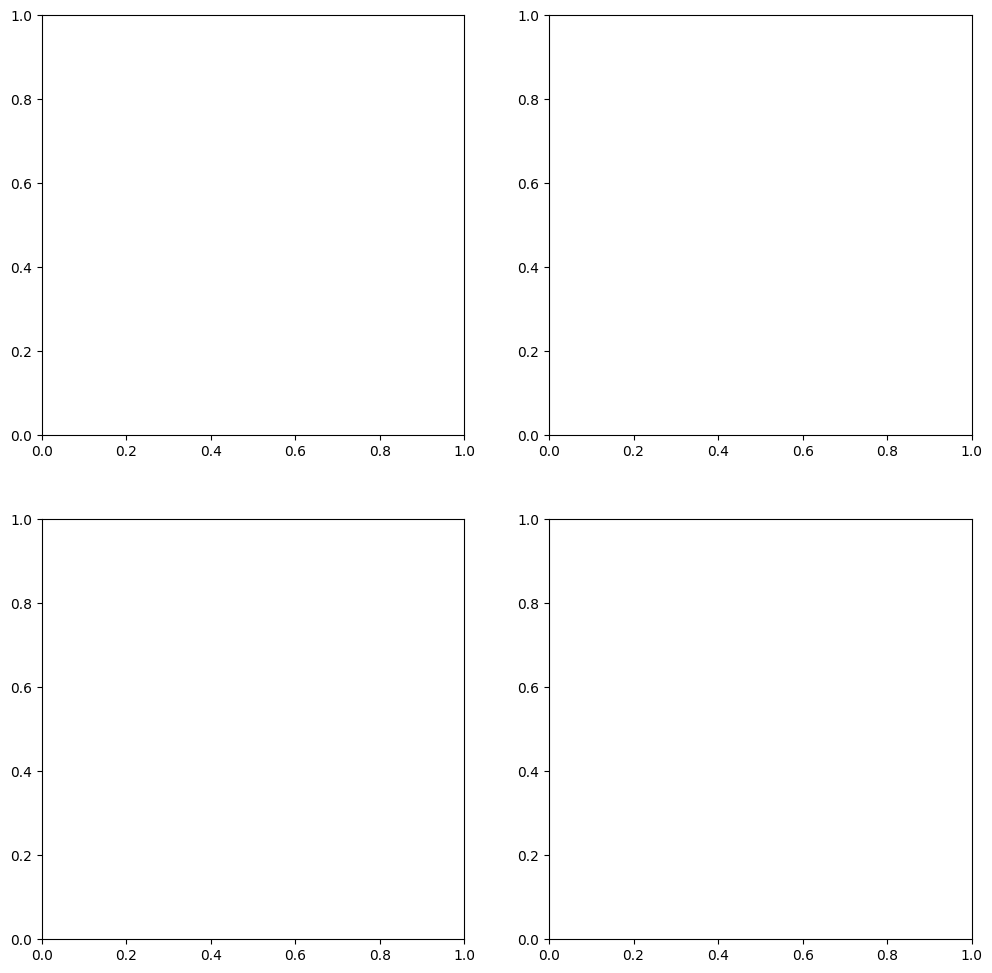

In [41]:
fig, axs = plt.subplots(2, 2, figsize=(12, 12))
axs = axs.flatten()
# fig.suptitle(
#     'Skirtumai keičiant metric SWISS duomenims ($k=15$, $min-dist=0.1$)',
#     fontsize=14
# )

for i, m in enumerate(metrics):
    plot_swiss(X_swiss, color, metric=m, ax=axs[i], var='metric')

plt.tight_layout()
plt.savefig("metric_swiss.png", dpi=300, bbox_inches="tight")
plt.show()

#### Kintamojo `n_epochs` įtaka

/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_stat

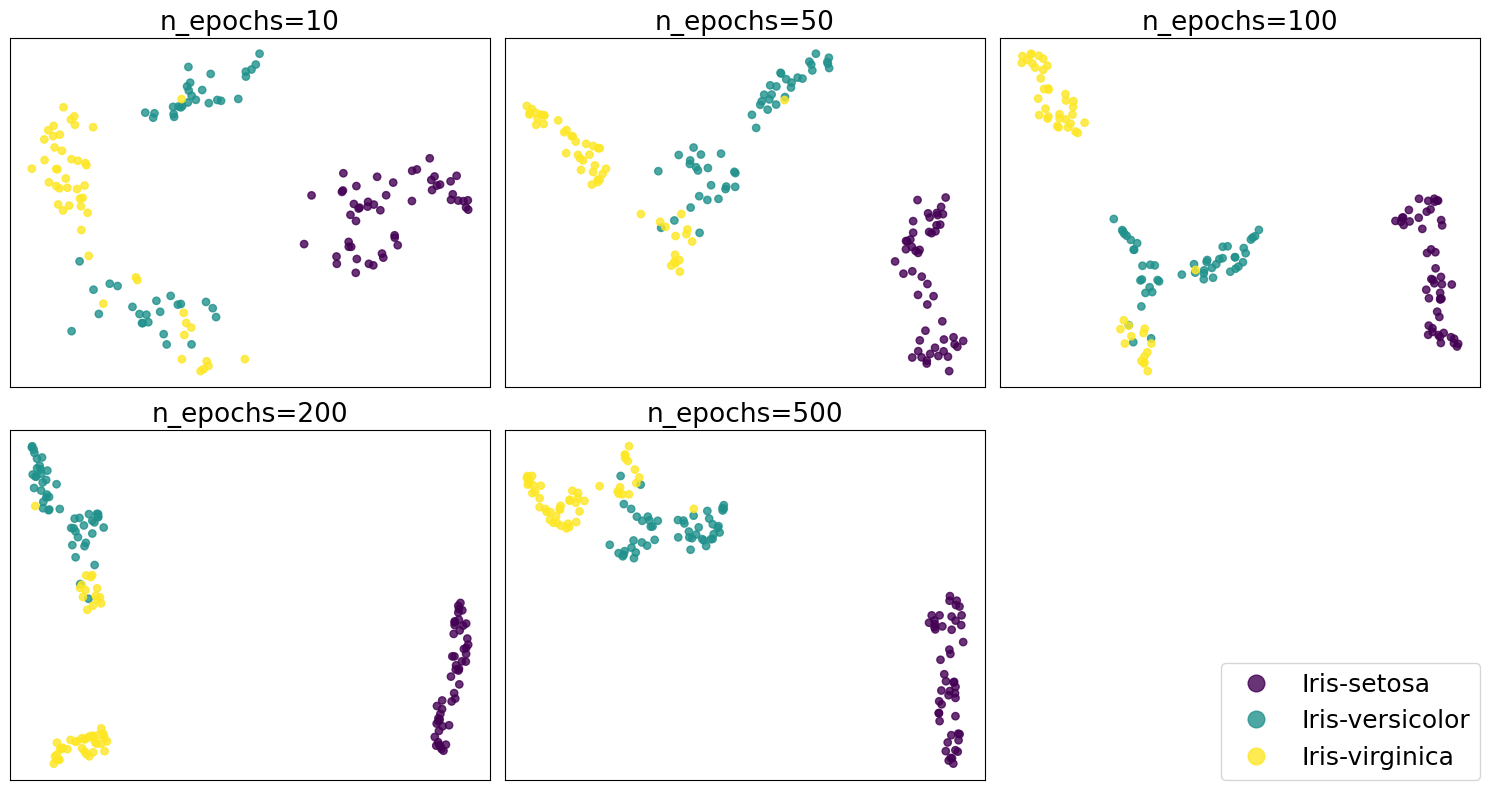

In [41]:
epochs_values = [10, 50, 100, 200, 500]
fig, axs = plt.subplots(2, 3, figsize=(15, 8))
axs = axs.flatten()
# fig.suptitle('Skirtumai keičiant n_epochs Iris duomenims ($k=15$, $min-dist=0.1$)', fontsize=14)

for i, e in enumerate(epochs_values):
    plot_iris(iris[[0, 1, 2, 3]], n_epochs=e, ax=axs[i], var='n_epochs')

axs[-1].axis('off')

fig.legend(
    handles,
    ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'],
    loc='lower right',
    fontsize=18,
    markerscale=2
)

plt.tight_layout()
plt.savefig("nepochs_iris.png", dpi=300, bbox_inches="tight")
plt.show()

/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_stat

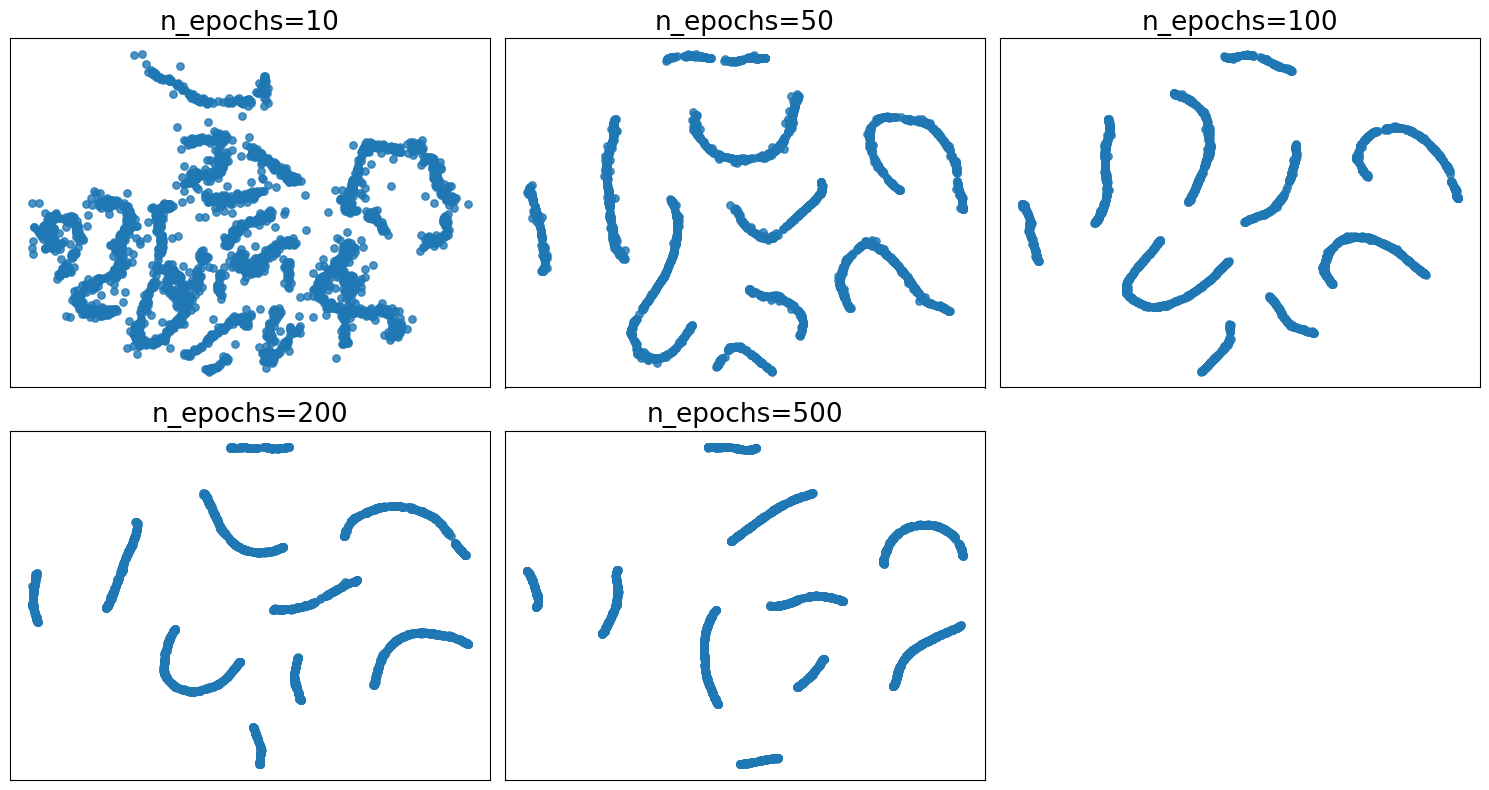

In [42]:
fig, axs = plt.subplots(2, 3, figsize=(15, 8))
axs = axs.flatten()
# fig.suptitle('Skirtumai keičiant n_epochs Ellipsoid duomenims ($k=15$, $min-dist=0.1$)', fontsize=14)

for i, e in enumerate(epochs_values):
    plot_ellipsoid(ellipsoid, n_epochs=e, ax=axs[i], var='n_epochs')

axs[-1].axis('off')

plt.tight_layout()
plt.savefig("nepochs_ellipsoid.png", dpi=300, bbox_inches="tight")
plt.show()

/home/user/Documents/repositories/ais-duomenu-vizualizavimas/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/user/Documents/repositories/ais-duomenu-vizualizavimas/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/user/Documents/repositories/ais-duomenu-vizualizavimas/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/user/Documents/repositories/ais-duomenu-vizualizavimas/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/user/Documents/repositories/ais-duomenu-vizualizavimas/.venv/lib/python3.12/site-packages/umap/umap_.py:19

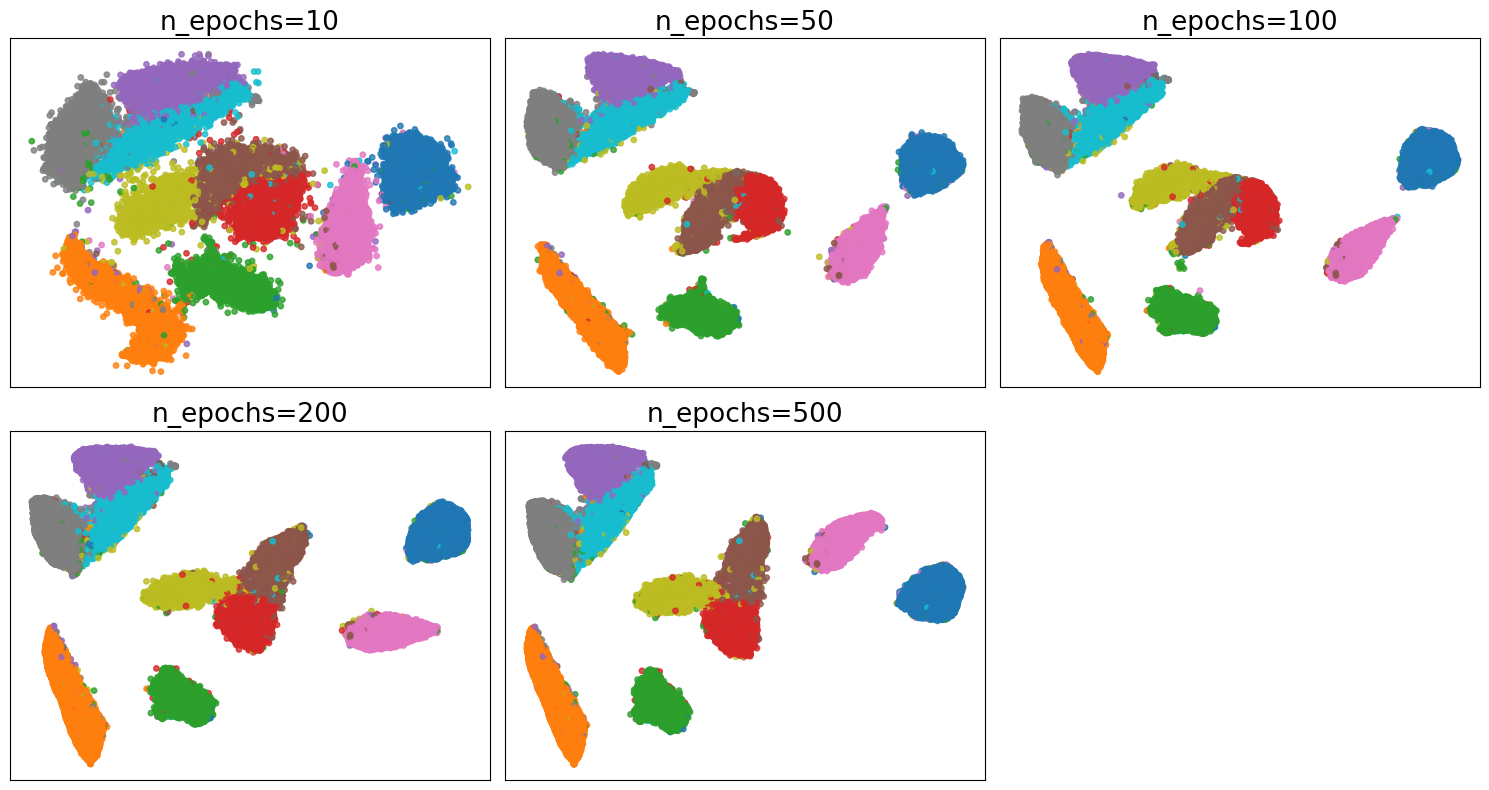

In [23]:
fig, axs = plt.subplots(2, 3, figsize=(15, 8))
axs = axs.flatten()
# fig.suptitle('Skirtumai keičiant n_epochs MNIST duomenims ($k=15$, $min-dist=0.1$)', fontsize=14)

for i, e in enumerate(epochs_values):
    plot_mnist(X_mnist, y, n_epochs=e, ax=axs[i], var='n_epochs')

axs[-1].axis('off')

plt.tight_layout()
plt.savefig("nepochs_mnist.png", dpi=300, bbox_inches="tight")
plt.show()

/home/user/Documents/repositories/ais-duomenu-vizualizavimas/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/user/Documents/repositories/ais-duomenu-vizualizavimas/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/user/Documents/repositories/ais-duomenu-vizualizavimas/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/user/Documents/repositories/ais-duomenu-vizualizavimas/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/user/Documents/repositories/ais-duomenu-vizualizavimas/.venv/lib/python3.12/site-packages/umap/umap_.py:19

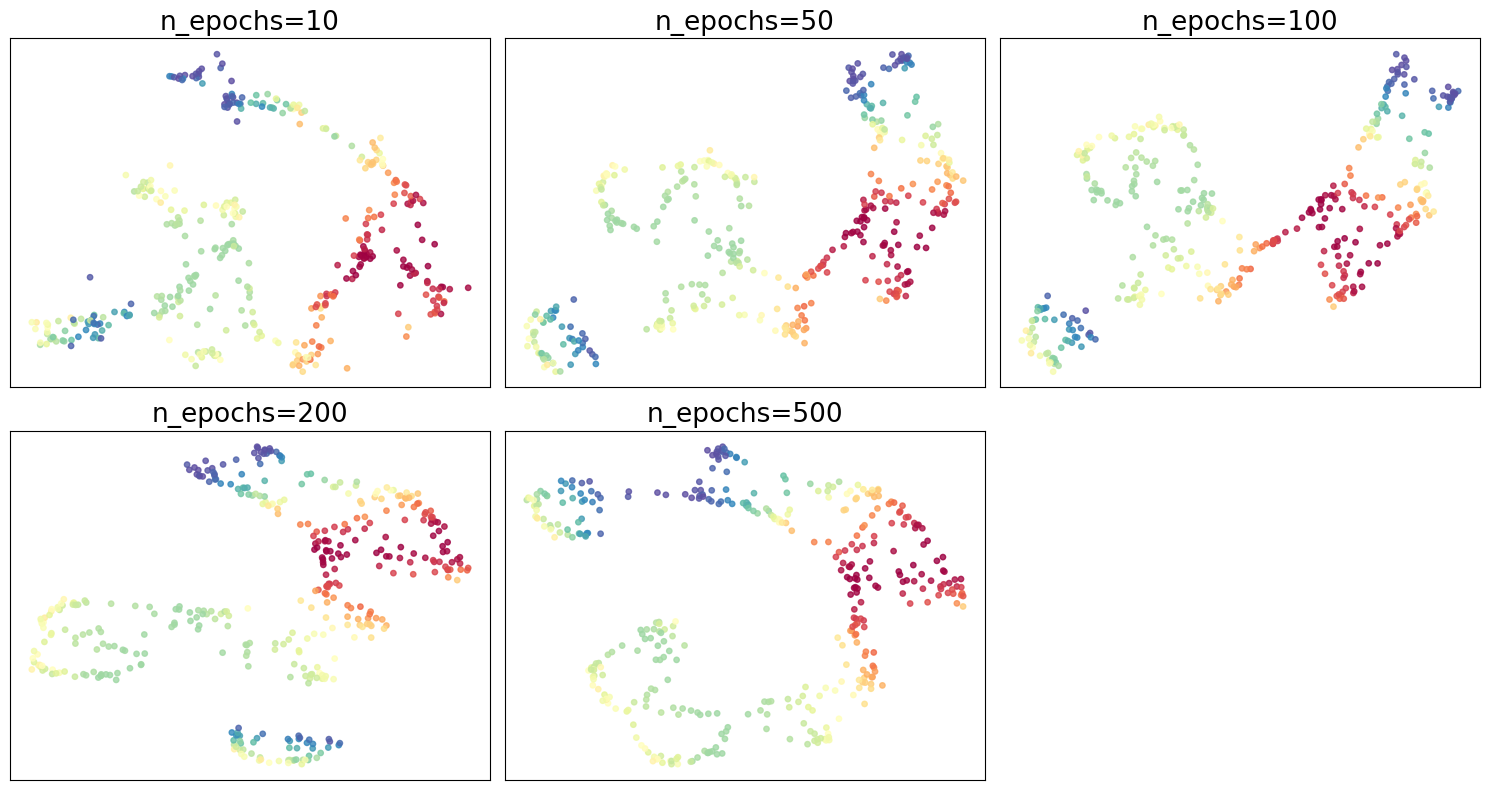

In [24]:
fig, axs = plt.subplots(2, 3, figsize=(15, 8))
axs = axs.flatten()
# fig.suptitle('Skirtumai keičiant n_epochs SWISS duomenims ($k=15$, $min-dist=0.1$)', fontsize=14)

for i, e in enumerate(epochs_values):
    plot_swiss(X_swiss, n_epochs=e, ax=axs[i], var='n_epochs')

axs[-1].axis('off')

plt.tight_layout()
plt.savefig("nepochs_swiss.png", dpi=300, bbox_inches="tight")
plt.show()

#### Kintamojo `learning_rate` įtaka

/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_stat

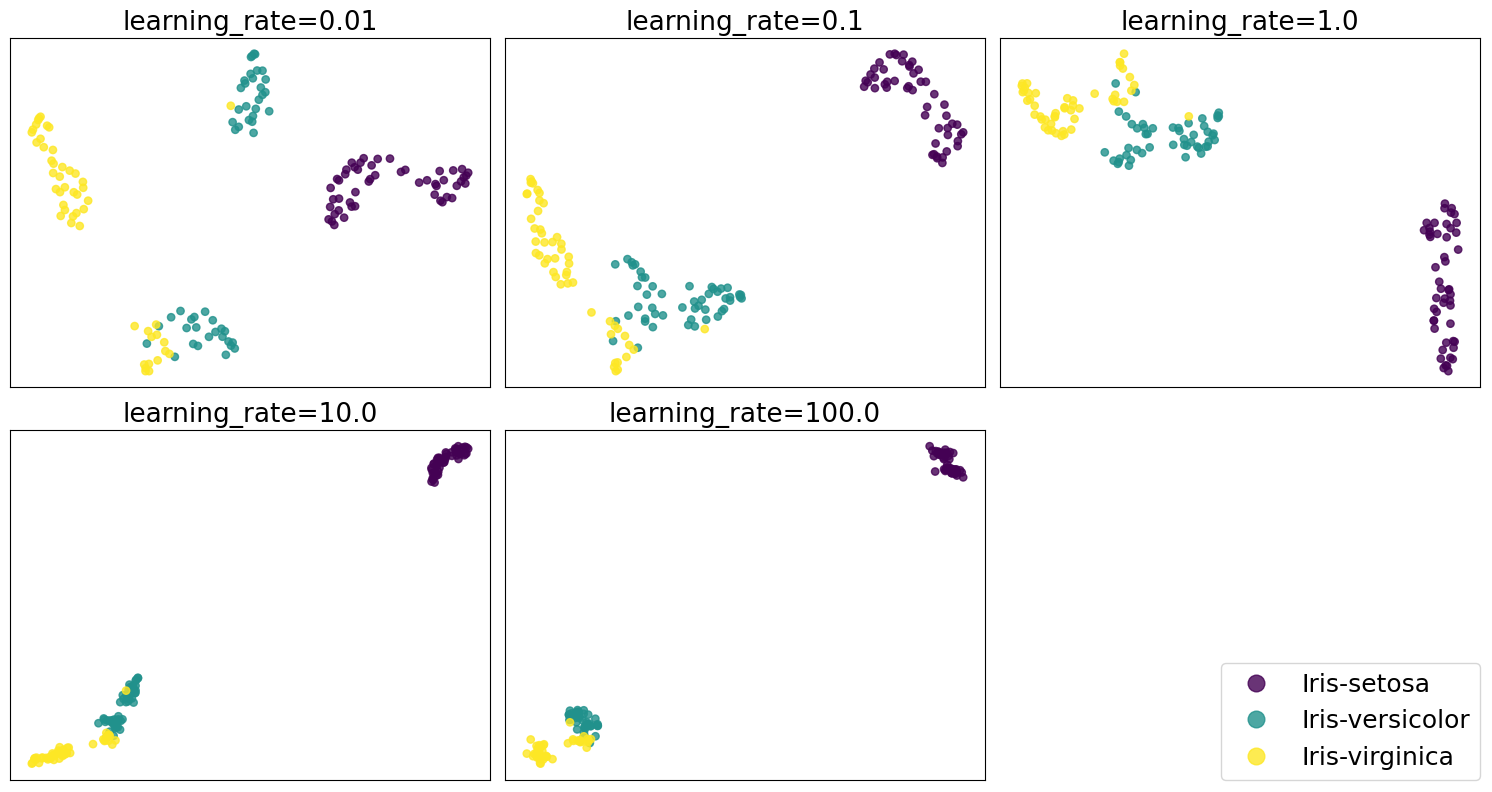

In [53]:
lr_values = [0.01, 0.1, 1.0, 10.0, 100.0]
fig, axs = plt.subplots(2, 3, figsize=(15, 8))
axs = axs.flatten()
# fig.suptitle('Skirtumai keičiant learning_rate Iris duomenims ($k=15$, $min-dist=0.1$)', fontsize=14)

for i, lr in enumerate(lr_values):
    plot_iris(iris[[0, 1, 2, 3]], learning_rate=lr, ax=axs[i], var='learning_rate')

axs[-1].axis('off')

fig.legend(
    handles,
    ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'],
    loc='lower right',
    fontsize=18,
    markerscale=2
)

plt.tight_layout()
plt.savefig("learningrate_iris.png", dpi=300, bbox_inches="tight")
plt.show()

/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/2Lab/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_stat

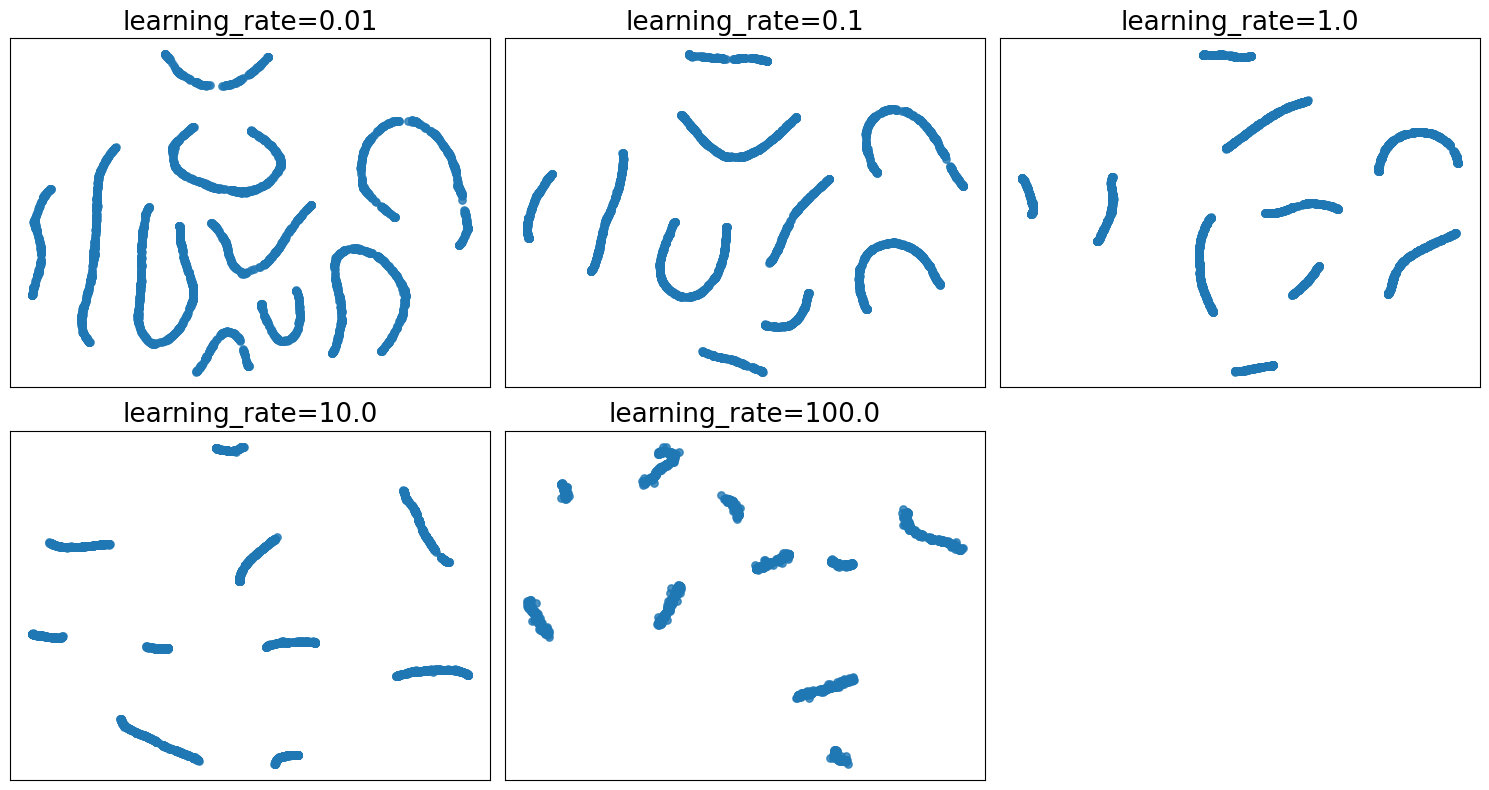

In [52]:
fig, axs = plt.subplots(2, 3, figsize=(15, 8))
axs = axs.flatten()
# fig.suptitle('Skirtumai keičiant learning_rate Ellipsoid duomenims ($k=15$, $min-dist=0.1$)', fontsize=14)

for i, lr in enumerate(lr_values):
    plot_ellipsoid(ellipsoid, learning_rate=lr, ax=axs[i], var='learning_rate')

axs[-1].axis('off')

plt.tight_layout()
plt.savefig("learningrate_ellipsoid.png", dpi=300, bbox_inches="tight")
plt.show()

/home/user/Documents/repositories/ais-duomenu-vizualizavimas/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/user/Documents/repositories/ais-duomenu-vizualizavimas/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/user/Documents/repositories/ais-duomenu-vizualizavimas/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/user/Documents/repositories/ais-duomenu-vizualizavimas/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/user/Documents/repositories/ais-duomenu-vizualizavimas/.venv/lib/python3.12/site-packages/umap/umap_.py:19

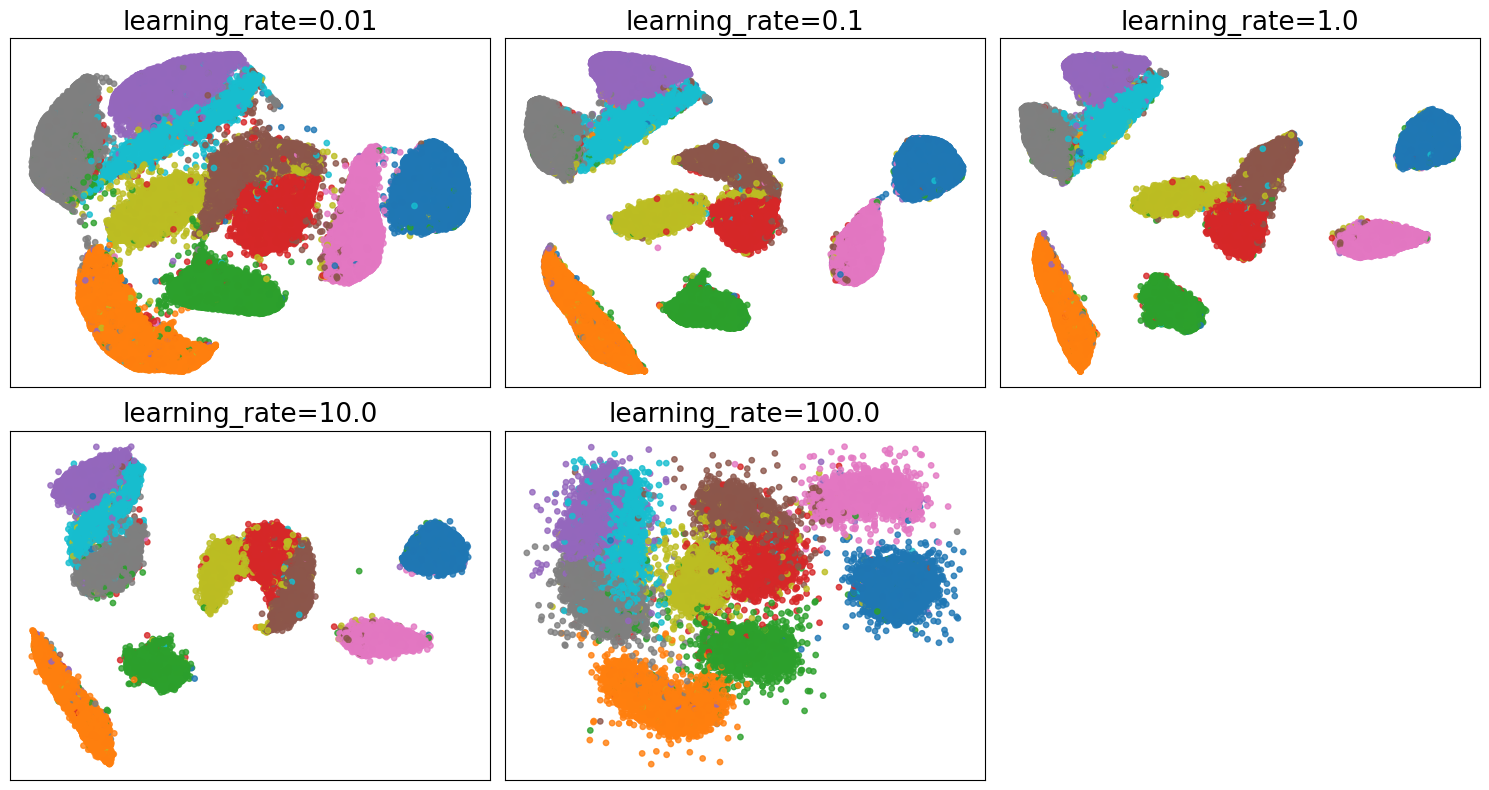

In [26]:
fig, axs = plt.subplots(2, 3, figsize=(15, 8))
axs = axs.flatten()
# fig.suptitle('Skirtumai keičiant learning_rate MNIST duomenims ($k=15$, $min-dist=0.1$)', fontsize=14)

for i, lr in enumerate(lr_values):
    plot_mnist(X_mnist, y, learning_rate=lr, ax=axs[i], var='learning_rate')

axs[-1].axis('off')

plt.tight_layout()
plt.savefig("learningrate_mnist.png", dpi=300, bbox_inches="tight")
plt.show()

/home/user/Documents/repositories/ais-duomenu-vizualizavimas/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/user/Documents/repositories/ais-duomenu-vizualizavimas/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/user/Documents/repositories/ais-duomenu-vizualizavimas/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/user/Documents/repositories/ais-duomenu-vizualizavimas/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/user/Documents/repositories/ais-duomenu-vizualizavimas/.venv/lib/python3.12/site-packages/umap/umap_.py:19

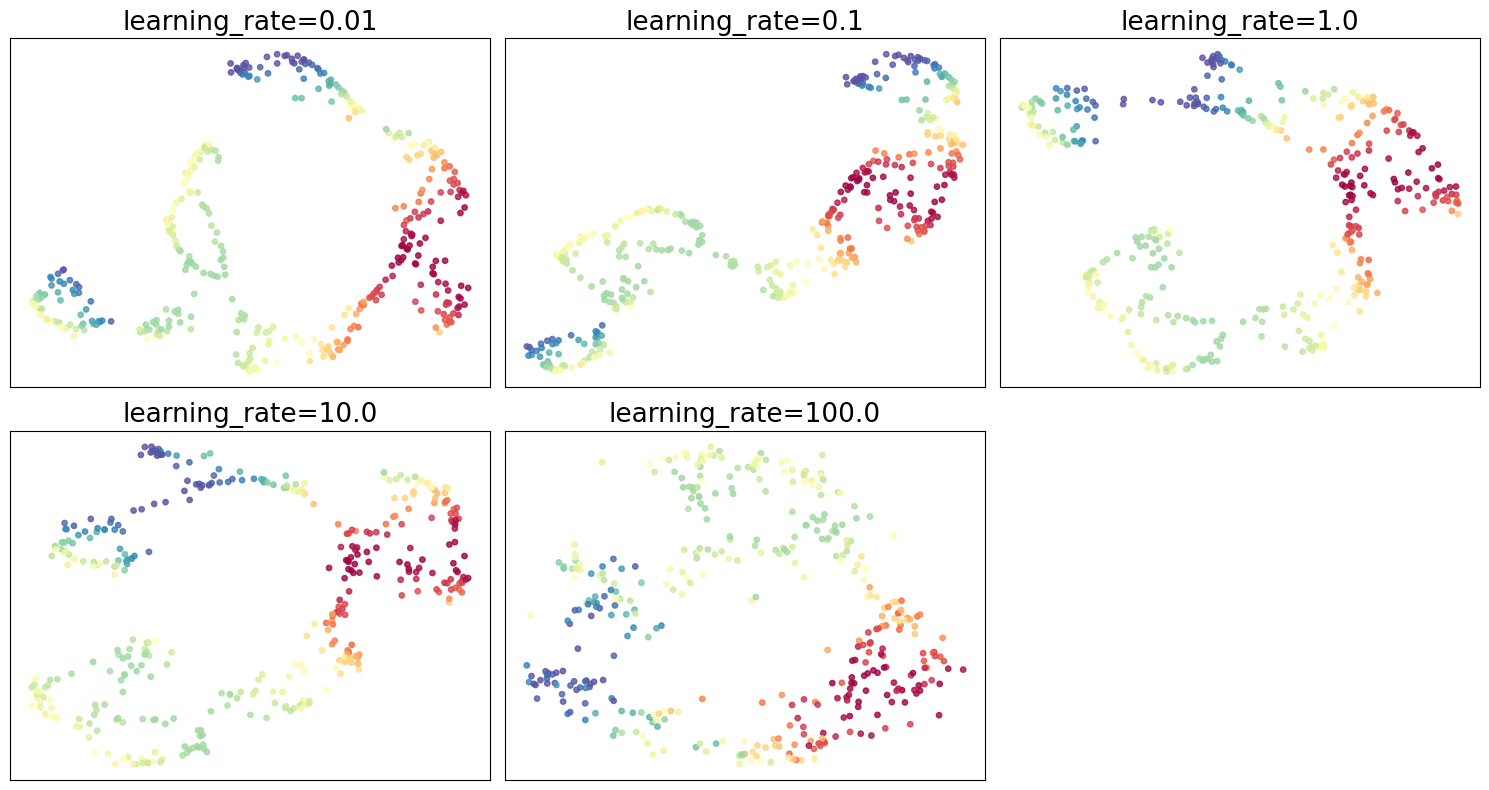

In [27]:
fig, axs = plt.subplots(2, 3, figsize=(15, 8))
axs = axs.flatten()
# fig.suptitle('Skirtumai keičiant learning_rate SWISS duomenims ($k=15$, $min-dist=0.1$)', fontsize=14)

for i, lr in enumerate(lr_values):
    plot_swiss(X_swiss, learning_rate=lr, ax=axs[i], var='learning_rate')

axs[-1].axis('off')

plt.tight_layout()
plt.savefig("learningrate_swiss.png", dpi=300, bbox_inches="tight")
plt.show()